# HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)

**Dataset** : Pendigits (UCI / OpenML) — 10 992 échantillons, 16 features, 10 classes (chiffres manuscrits 0–9)  
**Objectif** : Clustering non supervisé avec HDBSCAN, évaluation via ARI, NMI et Silhouette Score  
**Librairies** : scikit-learn, numpy, matplotlib, pandas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

Dataset complet: 10992 echantillons
Sous ensemble 50%: 5496 echantillons
Train: 3847 | Validation: 824 | Test: 825
Variance expliquee PCA 2D: 0.497
Variance expliquee PCA 10D: 0.967


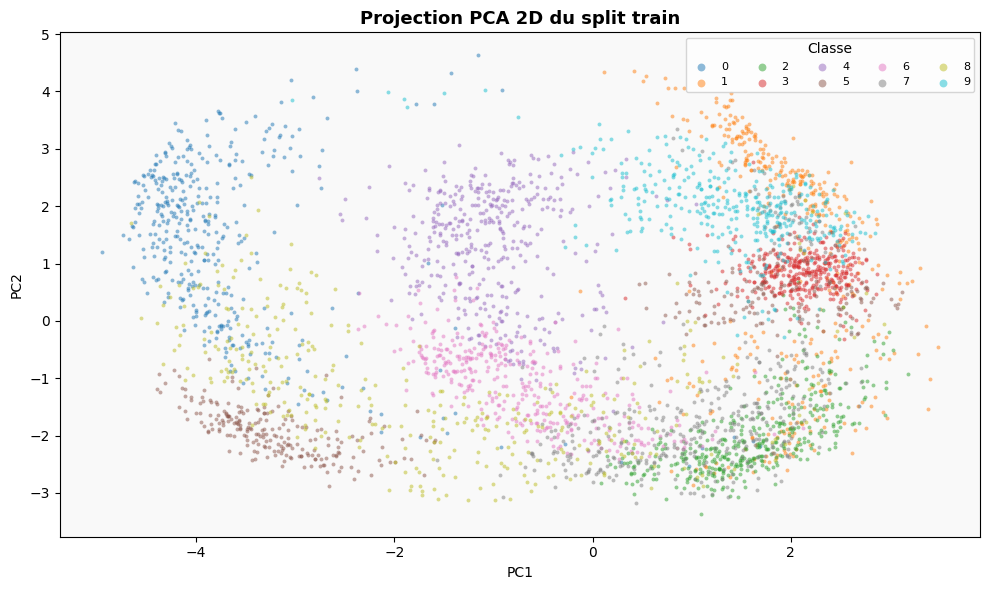

EDA sauvegardee: eda_pendigits_train_split.png


In [ ]:
# Chargement des donnees
pendigits = fetch_openml('pendigits', version=1, as_frame=True, parser='auto')
X_raw = pendigits.data.astype(float).values
y_raw = pendigits.target.astype(int).values

# Sous echantillonnage a 50%
X_half, _, y_half, _ = train_test_split(
    X_raw, y_raw,
    train_size=0.5,
    stratify=y_raw,
    random_state=42
)

# Split train 70%, validation 15%, test 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_half, y_half,
    test_size=0.30,
    stratify=y_half,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Dataset complet: {X_raw.shape[0]} echantillons")
print(f"Sous ensemble 50%: {X_half.shape[0]} echantillons")
print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Standardisation sur train uniquement
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# PCA 2D pour visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)
X_val_pca2 = pca_2d.transform(X_val_scaled)
X_test_pca2 = pca_2d.transform(X_test_scaled)

# PCA 10D pour HDBSCAN
pca_10d = PCA(n_components=10, random_state=42)
X_train_pca10 = pca_10d.fit_transform(X_train_scaled)
X_val_pca10 = pca_10d.transform(X_val_scaled)
X_test_pca10 = pca_10d.transform(X_test_scaled)

print(f"Variance expliquee PCA 2D: {pca_2d.explained_variance_ratio_.sum():.3f}")
print(f"Variance expliquee PCA 10D: {pca_10d.explained_variance_ratio_.sum():.3f}")

# Visualisation rapide du train en PCA 2D
colors_true = plt.cm.tab10(np.linspace(0, 1, 10))
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
for cls in range(10):
    mask = y_train == cls
    ax.scatter(
        X_train_pca2[mask, 0],
        X_train_pca2[mask, 1],
        c=[colors_true[cls]],
        label=str(cls),
        s=8,
        alpha=0.5,
        linewidths=0
    )
ax.set_title('Projection PCA 2D du split train', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Classe', ncol=5, fontsize=8, markerscale=2, loc='upper right')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()
print('EDA sauvegardee: eda_pendigits_train_split.png')

In [3]:
# Tuning HDBSCAN avec validation uniquement
param_grid = {
    'min_cluster_size': [20, 30, 40, 60, 80, 100, 140],
    'min_samples': [5, 10, 15, 20, 30],
    'cluster_selection_method': ['eom', 'leaf'],
    'cluster_selection_epsilon': [0.0, 0.05, 0.1, 0.2]
}

ari_min = 0.50
nmi_min = 0.70

print('Intervalles de tuning proposes')
print(f"min_cluster_size: {param_grid['min_cluster_size']}")
print(f"min_samples: {param_grid['min_samples']}")
print(f"cluster_selection_method: {param_grid['cluster_selection_method']}")
print(f"cluster_selection_epsilon: {param_grid['cluster_selection_epsilon']}")
print(f"Filtre minimum validation ARI: {ari_min}")
print(f"Filtre minimum validation NMI: {nmi_min}")
print()

def evaluate_split(name, X, y_true, labels):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels)

    print(f"{name}")
    print(f"Clusters detectes: {n_clusters}")
    print(f"Points de bruit: {n_noise} ({noise_ratio:.2%})")

    mask_valid = labels != -1
    if mask_valid.sum() < 2 or len(np.unique(labels[mask_valid])) < 2:
        print('Metriques non disponibles: pas assez de clusters valides')
        print()
        return {
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'ari': np.nan,
            'nmi': np.nan,
            'silhouette': np.nan,
            'valid': False
        }

    X_valid = X[mask_valid]
    y_valid = y_true[mask_valid]
    labels_valid = labels[mask_valid]

    ari = adjusted_rand_score(y_valid, labels_valid)
    nmi = normalized_mutual_info_score(y_valid, labels_valid)
    sample_size = min(3000, len(X_valid))
    sil = silhouette_score(X_valid, labels_valid, sample_size=sample_size, random_state=42)

    print(f"ARI: {ari:.4f}")
    print(f"NMI: {nmi:.4f}")
    print(f"Silhouette: {sil:.4f}")
    print()

    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'ari': ari,
        'nmi': nmi,
        'silhouette': sil,
        'valid': True
    }

def validation_score(metrics, ari_minimum, nmi_minimum):
    if not metrics['valid']:
        return -1e9, False, 'invalid_metrics'

    if metrics['ari'] < ari_minimum or metrics['nmi'] < nmi_minimum:
        soft_score = metrics['ari'] + metrics['nmi']
        return -1e6 + soft_score, False, 'below_thresholds'

    cluster_alignment = 1 - min(abs(metrics['n_clusters'] - 10), 10) / 10
    sil_norm = (metrics['silhouette'] + 1.0) / 2.0
    score = (
        0.30 * metrics['ari']
        + 0.30 * metrics['nmi']
        + 0.25 * sil_norm
        + 0.10 * (1 - metrics['noise_ratio'])
        + 0.05 * cluster_alignment
    )
    return score, True, 'eligible'

results = []
total = (
    len(param_grid['min_cluster_size'])
    * len(param_grid['min_samples'])
    * len(param_grid['cluster_selection_method'])
    * len(param_grid['cluster_selection_epsilon'])
)
trial = 0

for min_cluster_size in param_grid['min_cluster_size']:
    for min_samples in param_grid['min_samples']:
        for cluster_selection_method in param_grid['cluster_selection_method']:
            for cluster_selection_epsilon in param_grid['cluster_selection_epsilon']:
                trial += 1
                params = {
                    'min_cluster_size': min_cluster_size,
                    'min_samples': min_samples,
                    'metric': 'euclidean',
                    'cluster_selection_method': cluster_selection_method,
                    'cluster_selection_epsilon': cluster_selection_epsilon
                }

                model_train = HDBSCAN(**params)
                labels_train_candidate = model_train.fit_predict(X_train_pca10)

                model_val = HDBSCAN(**params)
                labels_val_candidate = model_val.fit_predict(X_val_pca10)

                metrics_val = evaluate_split('Validation', X_val_pca10, y_val, labels_val_candidate)
                score_val, eligible_val, eligibility_reason = validation_score(metrics_val, ari_min, nmi_min)

                results.append({
                    'trial': trial,
                    'params': params,
                    'score_val': score_val,
                    'eligible_val': eligible_val,
                    'eligibility_reason': eligibility_reason,
                    'metrics_val': metrics_val
                })

                status = 'eligible' if eligible_val else 'rejete'
                print(f"Essai {trial}/{total} score validation: {score_val:.4f} statut: {status}")
                print()

eligible_results = [r for r in results if r['eligible_val']]
if len(eligible_results) > 0:
    results_sorted = sorted(eligible_results, key=lambda x: x['score_val'], reverse=True)
    print(f"Combinaisons eligibles: {len(eligible_results)} sur {len(results)}")
else:
    results_sorted = sorted(results, key=lambda x: x['score_val'], reverse=True)
    print('Aucune combinaison ne passe le filtre ARI/NMI, selection sur score de secours.')

best_result = results_sorted[0]
best_params = best_result['params']

print('Top 5 combinaisons validation')
for rank, item in enumerate(results_sorted[:5], start=1):
    m = item['metrics_val']
    p = item['params']
    elig = 'eligible' if item['eligible_val'] else item['eligibility_reason']
    print(
        f"{rank}. score={item['score_val']:.4f} | "
        f"statut={elig} | "
        f"min_cluster_size={p['min_cluster_size']} | "
        f"min_samples={p['min_samples']} | "
        f"method={p['cluster_selection_method']} | "
        f"epsilon={p['cluster_selection_epsilon']} | "
        f"clusters={m['n_clusters']} | bruit={m['noise_ratio']:.2%} | "
        f"ARI={m['ari']:.4f} | NMI={m['nmi']:.4f} | SIL={m['silhouette']:.4f}"
    )

print()
print('Meilleure combinaison retenue pour le modele final')
print(best_params)
print()
print('Le test est reserve a la fin et execute dans la cellule finale uniquement.')

hdbscan_train = HDBSCAN(**best_params)
labels_train = hdbscan_train.fit_predict(X_train_pca10)
train_metrics = evaluate_split('Train', X_train_pca10, y_train, labels_train)

hdbscan_val_best = HDBSCAN(**best_params)
labels_val = hdbscan_val_best.fit_predict(X_val_pca10)
val_metrics = evaluate_split('Validation avec meilleure combinaison', X_val_pca10, y_val, labels_val)

cluster_ids_train, cluster_sizes_train = np.unique(labels_train[labels_train != -1], return_counts=True)
n_clusters_train = len(cluster_ids_train)
n_noise_train = np.sum(labels_train == -1)
noise_ratio_train = n_noise_train / len(labels_train)

Intervalles de tuning proposes
min_cluster_size: [20, 30, 40, 60, 80, 100, 140]
min_samples: [5, 10, 15, 20, 30]
cluster_selection_method: ['eom', 'leaf']
cluster_selection_epsilon: [0.0, 0.05, 0.1, 0.2]
Filtre minimum validation ARI: 0.5
Filtre minimum validation NMI: 0.7

Validation
Clusters detectes: 9
Points de bruit: 215 (26.09%)
ARI: 0.8128
NMI: 0.8872
Silhouette: 0.3376

Essai 1/280 score validation: 0.7961 statut: eligible

Validation
Clusters detectes: 9
Points de bruit: 215 (26.09%)
ARI: 0.8128
NMI: 0.8872
Silhouette: 0.3376

Essai 2/280 score validation: 0.7961 statut: eligible

Validation
Clusters detectes: 9
Points de bruit: 215 (26.09%)
ARI: 0.8128
NMI: 0.8872
Silhouette: 0.3376

Essai 3/280 score validation: 0.7961 statut: eligible

Validation
Clusters detectes: 9
Points de bruit: 215 (26.09%)
ARI: 0.8128
NMI: 0.8872
Silhouette: 0.3376

Essai 4/280 score validation: 0.7961 statut: eligible

Validation
Clusters detectes: 9
Points de bruit: 215 (26.09%)
ARI: 0.8128
NMI: 0.

In [4]:
if 'test_final_deja_fait' not in globals():
    test_final_deja_fait = False

if test_final_deja_fait:
    print('Test final deja execute dans cette session. Redemarre le kernel pour le relancer.')
else:
    hdbscan_test_final = HDBSCAN(**best_params)
    labels_test = hdbscan_test_final.fit_predict(X_test_pca10)
    evaluate_split('Test final', X_test_pca10, y_test, labels_test)
    test_final_deja_fait = True
    print('Test final execute une seule fois pour cette session.')
    print('Hyperparametres utilises pour le test final')
    print(best_params)

Test final
Clusters detectes: 9
Points de bruit: 315 (38.18%)
ARI: 0.9030
NMI: 0.9257
Silhouette: 0.4148

Test final execute une seule fois pour cette session.
Hyperparametres utilises pour le test final
{'min_cluster_size': 20, 'min_samples': 15, 'metric': 'euclidean', 'cluster_selection_method': 'leaf', 'cluster_selection_epsilon': 0.0}


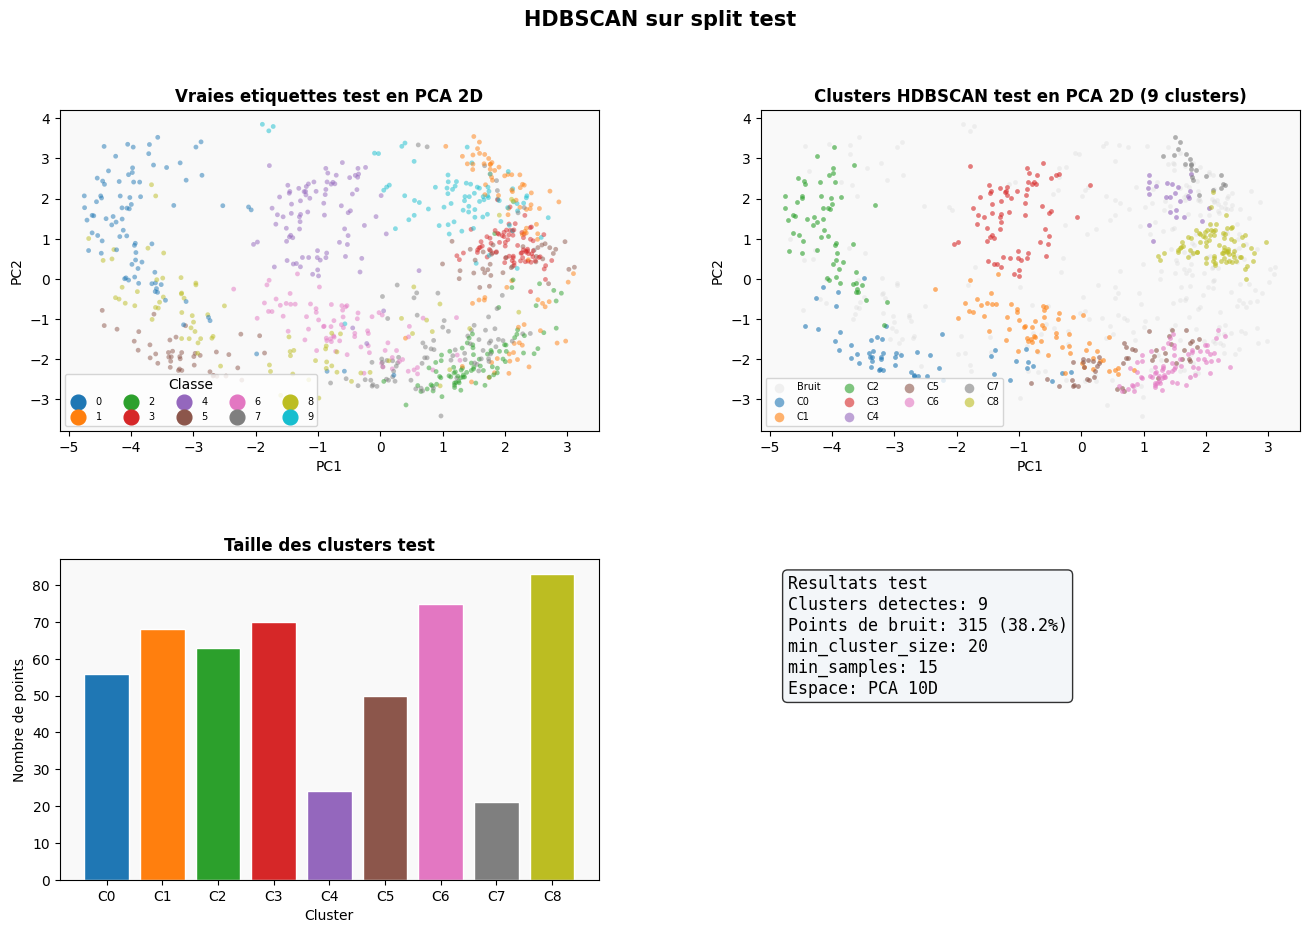

In [6]:
# Visualisation des resultats du split test
if 'labels_test' not in globals():
    print('Les labels du test ne sont pas encore calcules. Execute d abord la cellule de test final.')
else:
    cluster_ids_test, cluster_sizes_test = np.unique(labels_test[labels_test != -1], return_counts=True)
    n_clusters_test = len(cluster_ids_test)
    n_noise_test = np.sum(labels_test == -1)
    noise_ratio_test = n_noise_test / len(labels_test)

    palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters_test, 10)))
    color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(cluster_ids_test)}
    noise_color = np.array([0.75, 0.75, 0.75, 0.3])

    point_colors_pred_test = np.array([
        color_map[l] if l != -1 else noise_color for l in labels_test
    ])
    point_colors_true_test = np.array([colors_true[c] for c in y_test])

    fig = plt.figure(figsize=(16, 10), facecolor='white')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(X_test_pca2[:, 0], X_test_pca2[:, 1], c=point_colors_true_test, s=12, alpha=0.5, linewidths=0)
    ax1.set_title('Vraies etiquettes test en PCA 2D', fontsize=12, fontweight='bold')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_facecolor('#f9f9f9')
    for cls in range(10):
        ax1.scatter([], [], c=[colors_true[cls]], label=str(cls), s=50)
    ax1.legend(title='Classe', ncol=5, fontsize=7, markerscale=1.5)

    ax2 = fig.add_subplot(gs[0, 1])
    noise_mask_test = labels_test == -1
    ax2.scatter(
        X_test_pca2[noise_mask_test, 0],
        X_test_pca2[noise_mask_test, 1],
        c='lightgray',
        s=12,
        alpha=0.3,
        linewidths=0,
        label='Bruit'
    )
    for cid in cluster_ids_test:
        mask_c = labels_test == cid
        ax2.scatter(
            X_test_pca2[mask_c, 0],
            X_test_pca2[mask_c, 1],
            c=[color_map[cid]],
            s=12,
            alpha=0.6,
            linewidths=0,
            label=f'C{cid}'
        )
    ax2.set_title(f'Clusters HDBSCAN test en PCA 2D ({n_clusters_test} clusters)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_facecolor('#f9f9f9')
    ax2.legend(ncol=4, fontsize=7, markerscale=2)

    ax3 = fig.add_subplot(gs[1, 0])
    bar_colors = [color_map[cid] for cid in cluster_ids_test]
    ax3.bar([f'C{cid}' for cid in cluster_ids_test], cluster_sizes_test, color=bar_colors, edgecolor='white')
    ax3.set_title('Taille des clusters test', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Cluster')
    ax3.set_ylabel('Nombre de points')
    ax3.set_facecolor('#f9f9f9')

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    metrics_text = (
        f"Resultats test\n"
        f"Clusters detectes: {n_clusters_test}\n"
        f"Points de bruit: {n_noise_test} ({noise_ratio_test:.1%})\n"
        f"min_cluster_size: {best_params['min_cluster_size']}\n"
        f"min_samples: {best_params['min_samples']}\n"
        f"Espace: PCA 10D"
    )
    ax4.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax4.transAxes,
        fontsize=12,
        verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8)
    )
    ax4.set_facecolor('white')

    plt.suptitle('HDBSCAN sur split test', fontsize=15, fontweight='bold')
    plt.show()